# Comprehensive Mobile Price Analysis

## Data Loading and Exploration

In [31]:
import pandas as pd
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/Users/mariekrammer/Desktop/DI learning/week_4_ML_AI/day_3/train.csv')

In [6]:
print(df.head())
print(df.info())
print(df.columns)
print(df.shape)
print(df.describe())


   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  pc  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2   2         20       756  2549     9     7         19   
1        136        3   6        905      1988  2631    17     3          7   
2        145        5   6       1263      1716  2603    11     2          9   
3        131        6   9       1216      1786  2769    16     8         11   
4        141        2  14       1208      1212  1411     8     2         15   

   three_g  touch_screen  wifi  price_range 


Dataset columns are as follows:

- id - ID
- battery_power - Total energy a battery can store in one time measured in mAh
- blue - Has bluetooth or not
- clock_speed - Speed at which microprocessor executes instructions
- dual_sim - Has dual sim support or not
- fc - Front Camera mega pixels
- four_g - Has 4G or not
- int_memory - Internal Memory in Gigabytes
- m_dep - Mobile Depth in cm
- mobile_wt - Weight of mobile phone
- n_cores - Number of cores of processor
- pc - Primary Camera mega pixels
- px_height - Pixel Resolution Height
- px_width - Pixel Resolution Width
- ram - Random Access Memory in Megabytes
- sc_h - Screen Height of mobile in cm
- sc_w - Screen Width of mobile in cm
- talk_time - Longest time that a single battery charge will last when you are
- three_g - Has 3G or not
- touch_screen - Has touch screen or not
- wifi - Has wifi or not
- price_range - This is the target variable with value of:
0 (low cost)
1 (medium cost)
2 (high cost)
3 (very high cost)


### Duplicates :

In [10]:
print(df[df.duplicated()])

Empty DataFrame
Columns: [battery_power, blue, clock_speed, dual_sim, fc, four_g, int_memory, m_dep, mobile_wt, n_cores, pc, px_height, px_width, ram, sc_h, sc_w, talk_time, three_g, touch_screen, wifi, price_range]
Index: []


There is no duplicates and no missing value according to info()

### Feature enginering :

In [11]:
df['performance'] = df['ram'] * df['n_cores']

Screen quality:

In [13]:
df['screen_size'] = df['sc_h'] * df['sc_w']
df['resolution'] = df['px_height'] * df['px_width']

In [16]:
df_small = df.copy()
df_small = df_small.drop(['ram','n_cores','sc_h','sc_w','px_height','px_width'],axis = 1)

In [18]:
df_small.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,pc,talk_time,three_g,touch_screen,wifi,price_range,performance,screen_size,resolution
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,9.916500,11.011000,0.761500,0.503000,0.507000,1.500000,9614.580500,80.257000,9.052601e+05
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,6.064315,5.463955,0.426273,0.500116,0.500076,1.118314,7323.091307,76.824156,8.297625e+05
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,277.000000,0.000000,0.000000e+00
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,5.000000,6.000000,1.000000,0.000000,0.000000,0.750000,3524.000000,19.000000,2.632005e+05
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,10.000000,11.000000,1.000000,1.000000,1.000000,1.500000,7682.500000,55.000000,6.013590e+05
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,15.000000,16.000000,1.000000,1.000000,1.000000,2.250000,14197.500000,121.500000,1.359027e+06
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,20.000000,20.000000,1.000000,1.000000,1.000000,3.000000,31984.000000,342.000000,3.886306e+06


-battery power and clock_speed : seems like a normal distributuion
-blutooth : most of the phones have no blutooth

In [20]:
df_small.dtypes

battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
pc                 int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
performance        int64
screen_size        int64
resolution         int64
dtype: object

Everything is numerical, there is no need to Transform categorical data into numerical format using suitable methods.

### Statistical Analysis with NumPy and SciPy:

Execute detailed statistical analysis on each feature, including:
- Calculation of central tendency measures (mean, median, mode).
- Analysis of variability (range, variance, standard deviation).
- Evaluation of distribution shapes through skewness and kurtosis.

In [28]:
for col in df_small.columns:
    df_small[col] = df_small[col].values
    print(f'Mean of {col} is {np.mean(df_small[col])}')
    print(f'Median of {col} is {np.median(df_small[col])}')
    print(f'Mode of {col} is {stats.mode(df_small[col])}')
    print(f'Standard deviation of {col} is {np.std(df_small[col])}')
    print(f'Skew of {col} is {stats.skew(df_small[col])}')
    print(f'Kurtosis of {col} is {stats.kurtosis(df_small[col])}')
    print(' ')

Mean of battery_power is 1238.5185
Median of battery_power is 1226.0
Mode of battery_power is ModeResult(mode=array([618]), count=array([6]))
Standard deviation of battery_power is 439.3083377967575
Skew of battery_power is 0.03187454295305568
Kurtosis of battery_power is -1.224084165725428
 
Mean of blue is 0.495
Median of blue is 0.0
Mode of blue is ModeResult(mode=array([0]), count=array([1010]))
Standard deviation of blue is 0.4999749993749687
Skew of blue is 0.02000100007500624
Kurtosis of blue is -1.9995999599959997
 
Mean of clock_speed is 1.52225
Median of clock_speed is 1.5
Mode of clock_speed is ModeResult(mode=array([0.5]), count=array([413]))
Standard deviation of clock_speed is 0.8158001823363366
Skew of clock_speed is 0.17795052935349268
Kurtosis of clock_speed is -1.3231094949498647
 
Mean of dual_sim is 0.5095
Median of dual_sim is 1.0
Mode of dual_sim is ModeResult(mode=array([1]), count=array([1019]))
Standard deviation of dual_sim is 0.499909741853467
Skew of dual_si

/var/folders/76/79y9ksqx4kq5m3hsj5fpshhw0000gn/T/ipykernel_65886/2077870666.py:5: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  print(f'Mode of {col} is {stats.mode(df_small[col])}')


Skewness near 0 and small kurtosis : battery_power, blue,clock_speed,dual_sim,four_g,int_memory, m_dep, mobile_wt,pc,talk_time,touch_screen,wifi,price_range,

symetrical distribution and thin tail (not so much outliers)

skewness near 1 and small kurtosis : fc, performance,screen_size, resolution

right skewed and thin tail

skewness < 0 and small kurtosis : three_g, left skewed and thin tail

#### Perform hypothesis testing for statistical significance between groups (e.g., different price ranges).

HO: there is no difference between the phones of different price ranges

In [30]:

for col in df_small.columns:
    groups = []
    for price in df_small['price_range'].unique():
        group = df_small[df_small['price_range']==price][col].values
        groups.append(group)
    F_stat, p_value = stats.f_oneway(*groups)
    print(f'Concerning the column {col}')
    print(f'F_stat = {F_stat}')
    print(f'p_value = {p_value}')
    print(' ')

Concerning the column battery_power
F_stat = 31.598157539897333
p_value = 5.948688277085545e-20
 
Concerning the column blue
F_stat = 0.4767677091173066
p_value = 0.6984831100963985
 
Concerning the column clock_speed
F_stat = 0.49370780102855016
p_value = 0.6866751621401248
 
Concerning the column dual_sim
F_stat = 0.4282392855760518
p_value = 0.7327869305726169
 
Concerning the column fc
F_stat = 0.7721819601852685
p_value = 0.5095041590900421
 
Concerning the column four_g
F_stat = 1.0595245262722717
p_value = 0.3651552008381206
 
Concerning the column int_memory
F_stat = 2.922996079417897
p_value = 0.03277693883277447
 
Concerning the column m_dep
F_stat = 1.500682439668271
p_value = 0.21245949273717601
 
Concerning the column mobile_wt
F_stat = 3.594318185153689
p_value = 0.013117390712873744
 
Concerning the column pc
F_stat = 0.8254463576890607
p_value = 0.4797489023362932
 
Concerning the column talk_time
F_stat = 1.6288113087355847
p_value = 0.18066864736912272
 
Concerning th

We do not reject H0: battery_power,bluetooth,clock_speed,dual_sim,fc,m_dep,four_g,pc,talk_time,three_g,touch_screen,wifi,screen_size,resolution, pc, talk_time,three_g,touch_screen, wifi, screen_size

#### We reject H0:      int_memory,mobile_wt,performance, resolution, battery_power


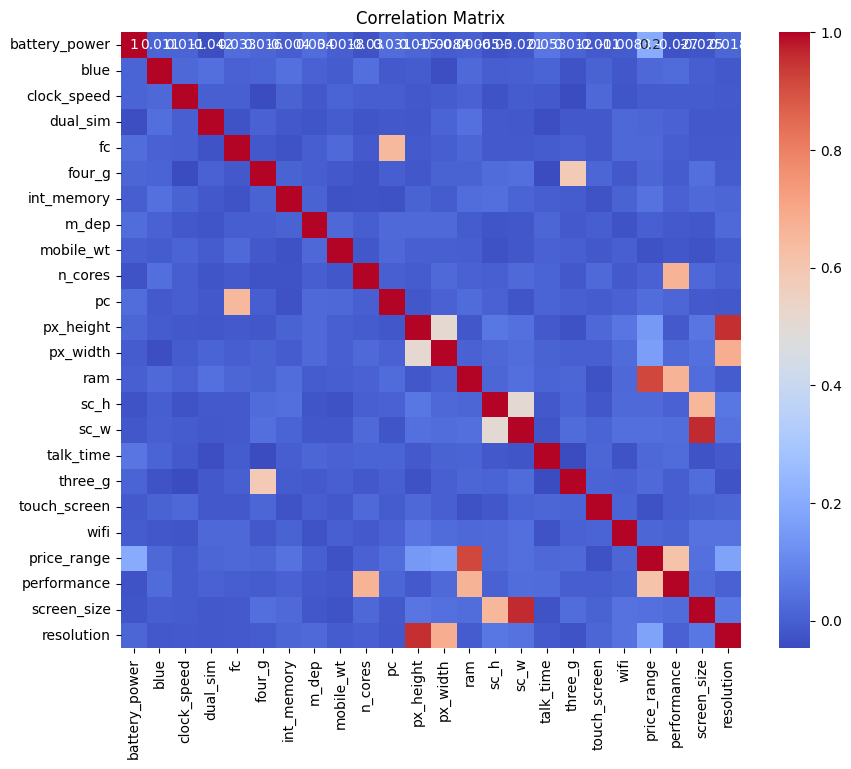

In [35]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### strong corolation from the original data set : px_height and resolution, ram and price range, sc_w and screen_size

medium corolation : fc and pc, 4g and 3g, n_cores and performance, ram and performance,sc_w and screen_size, price_range and performance

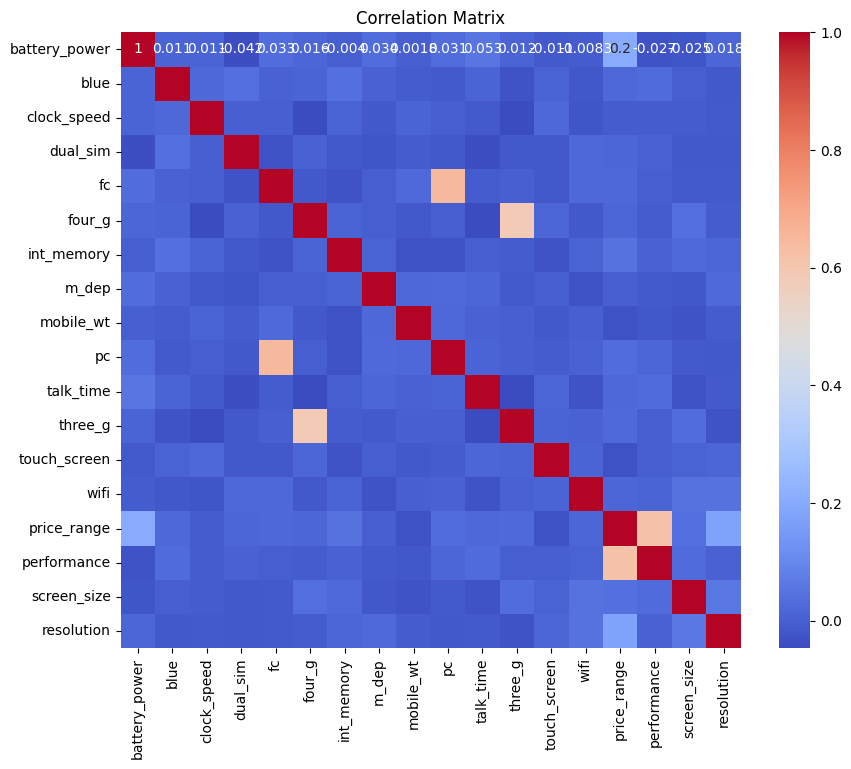

In [36]:
plt.figure(figsize=(10,8))
sns.heatmap(df_small.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### corolation from the modified data set : pc and fc, 3g and 4g, price range nd performance

In [40]:
# Pearson
corr_p, p_p = stats.pearsonr(df['ram'], df['price_range'])

# Spearman
corr_s, p_s = stats.spearmanr(df['ram'], df['price_range'])

print("Pearson:", corr_p)
print("Spearman:", corr_s)

Pearson: 0.9170457362649975
Spearman: 0.9170797841496084


This confirms the map : strong corolation between ram and price, linar relation

In [41]:
# Pearson
corr_p, p_p = stats.pearsonr(df['performance'], df['price_range'])

# Spearman
corr_s, p_s = stats.spearmanr(df['performance'], df['price_range'])

print("Pearson:", corr_p)
print("Spearman:", corr_s)

Pearson: 0.6149581286122665
Spearman: 0.6274973940370352


this confirms the map : corolation between performance and price, linear relation

In [47]:
# Pearson
corr_p, p_p = stats.pearsonr(df['performance'], df['price_range'])

# Spearman
corr_s, p_s = stats.spearmanr(df['performance'], df['price_range'])

print("Pearson:", corr_p)
print("Spearman:", corr_s)

Pearson: 0.6149581286122665
Spearman: 0.6274973940370352


We are going to apply advanced SciPy statistical functions for deeper insights:

In [49]:
# Pearson
corr_p,p_p = stats.pearsonr(df['int_memory'],df['price_range'])

#Spearman 
corr_s,p_s = stats.spearmanr(df['int_memory'],df['price_range'])


print("Pearson:", corr_p)
print("Spearman:", corr_s)

Pearson: 0.04443495938898787
Spearman: 0.04427752850862638


Acording to the p_value, there is a relation but it is realy small corolated, we can ignore it

In [50]:
#Pearson
corr_p, p_p = stats.pearsonr(df['resolution'],df['price_range'])

#Spearman
corr_s,p_s = stats.spearmanr(df['resolution'],df['price_range'])


print("Pearson:", corr_p)
print("Spearman:", corr_s)Acording to the p_value, there is a relation but it is realy small corolated, we can ignore it

Pearson: 0.17623988317251746
Spearman: 0.1577741300087108


Acording to the p_value, there is a relation but it is realy small corolated, 

In [52]:
#Pearson
corr_p, p_p = stats.pearsonr(df['mobile_wt'],df['price_range'])

#Spearman
corr_s,p_s = stats.spearmanr(df['mobile_wt'],df['price_range'])


print("Pearson:", corr_p)
print("Spearman:", corr_s)

Pearson: -0.030302171314386624
Spearman: -0.030214005836468487


Acording to the p_value, there is a relation but it is realy small corolated, we can ignore it

In [60]:
# Pearson
corr_p, p_p = stats.pearsonr(df['battery_power'], df['price_range'])

# Spearman
corr_s, p_s = stats.spearmanr(df['battery_power'], df['price_range'])

print("Pearson:", corr_p)
print("Spearman:", corr_s)

Pearson: 0.2007226121137326
Spearman: 0.19999095450908858


Acording to the p_value, there is a relation but it is realy small corolated, 

## Data Visualization with Matplotlib:

Text(0.5, 1.0, 'Performance vs price_range')

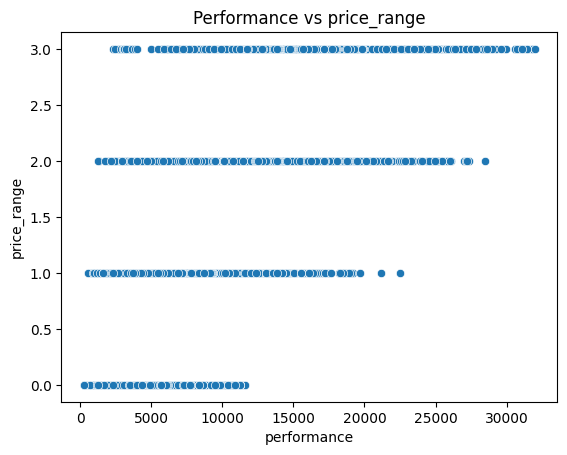

In [57]:
sns.scatterplot(df_small, x='performance',y='price_range')
plt.title("Performance vs price_range")

Text(0.5, 1.0, 'Ram vs price_range')

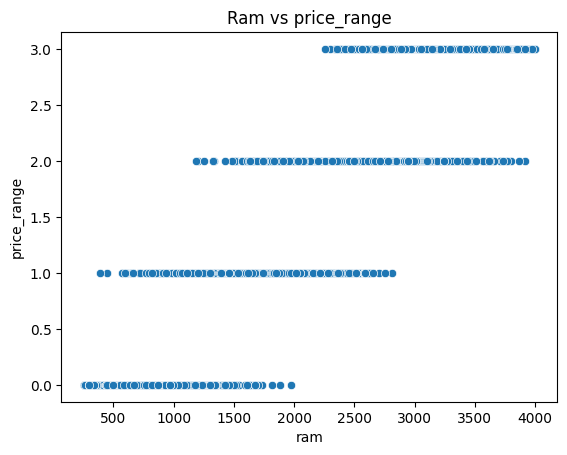

In [59]:
sns.scatterplot(df, x='ram',y='price_range')
plt.title("Ram vs price_range")

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


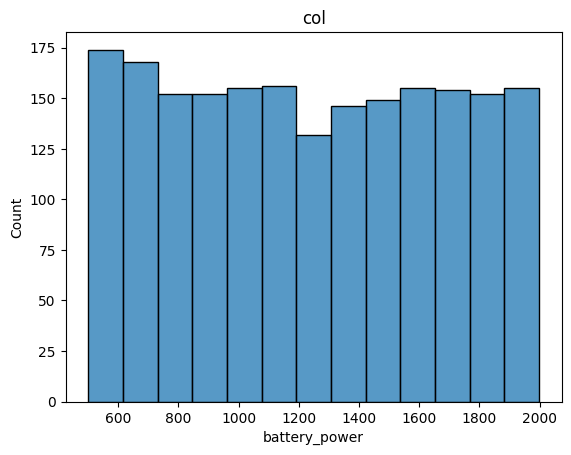

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


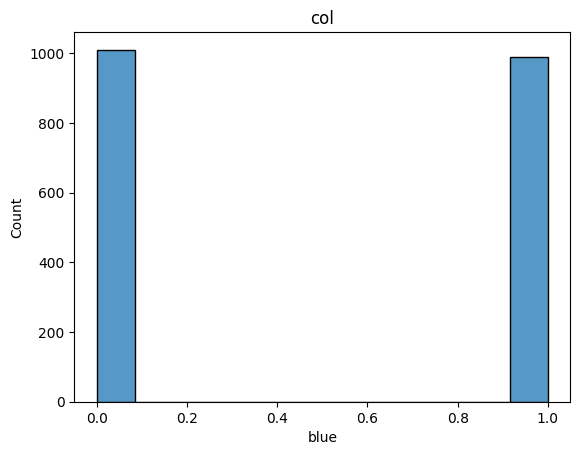

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


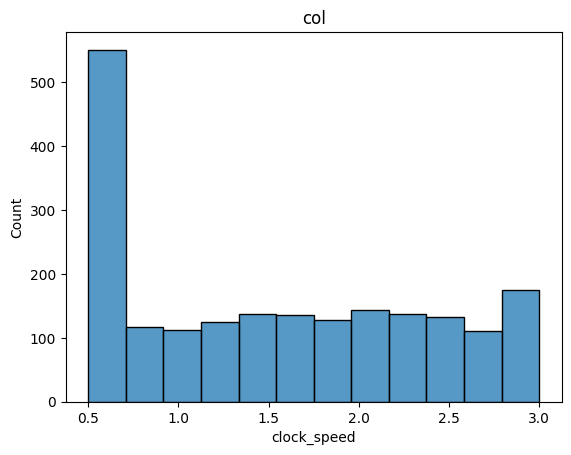

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


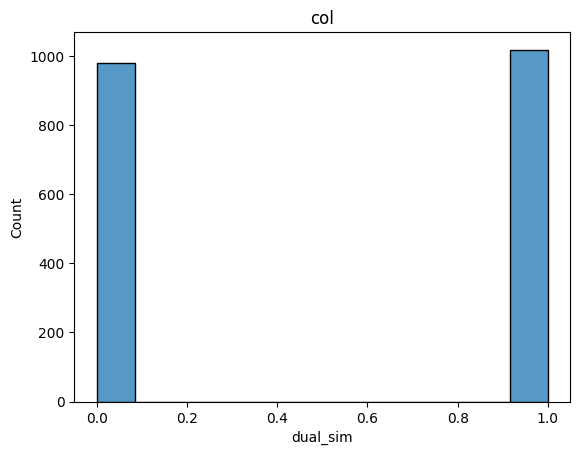

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


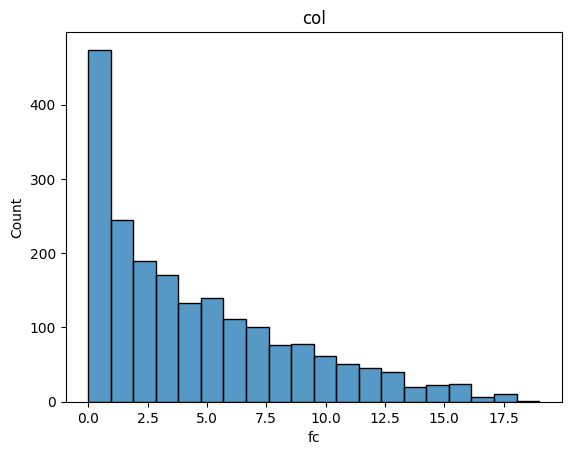

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


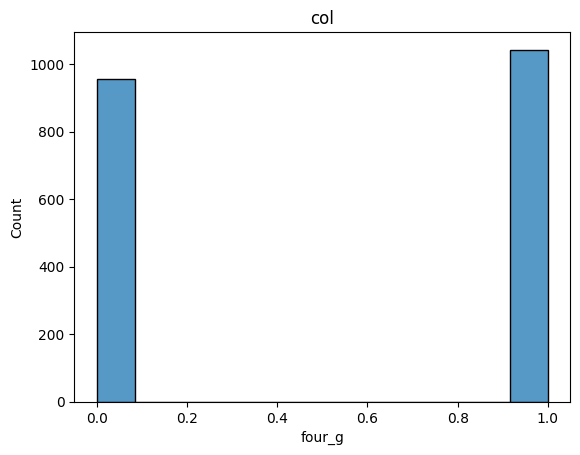

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


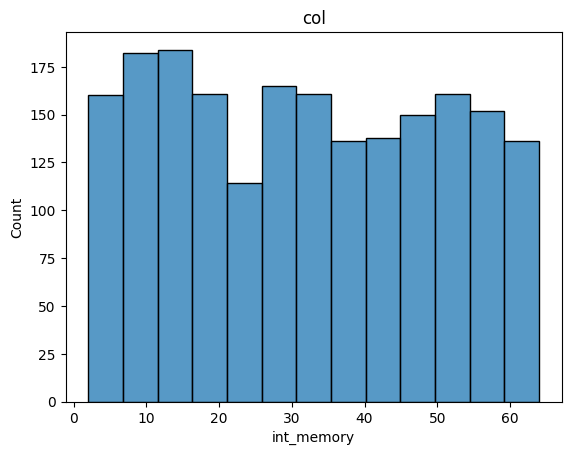

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


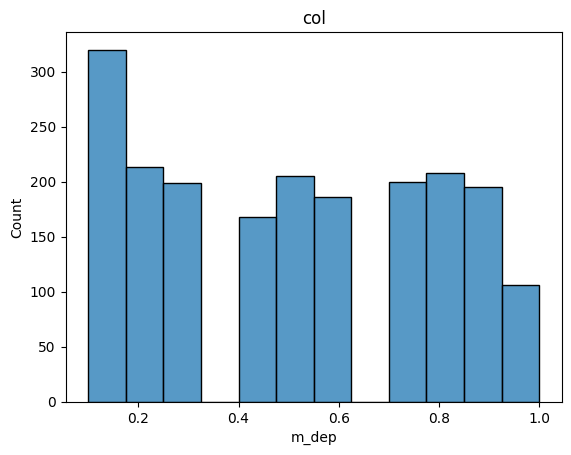

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


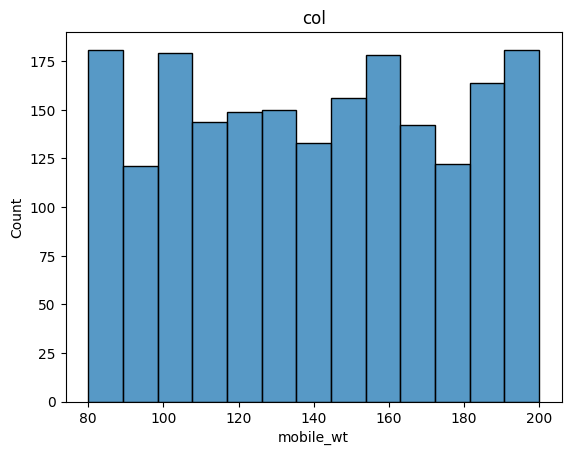

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


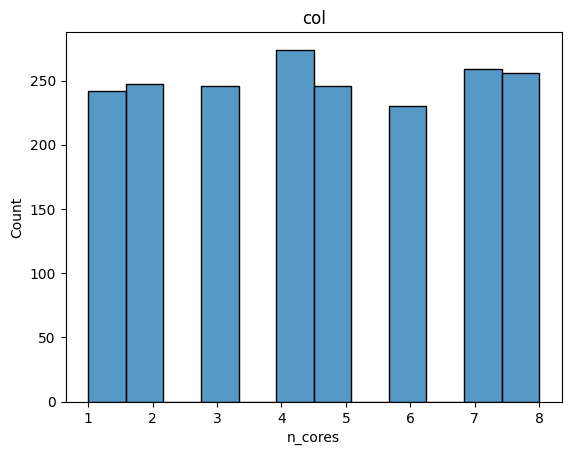

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


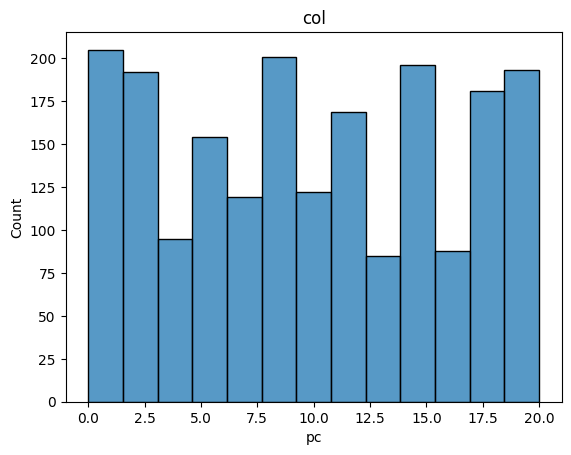

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


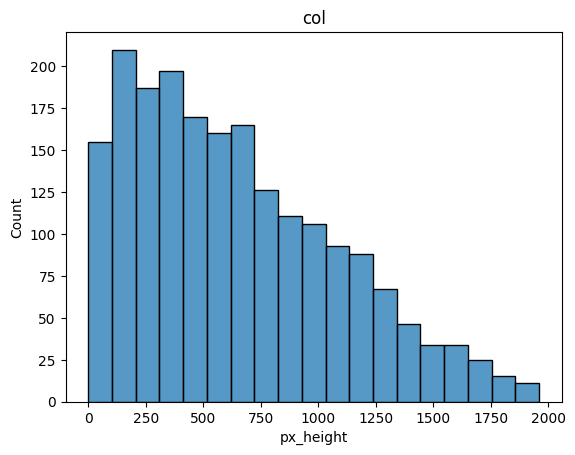

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


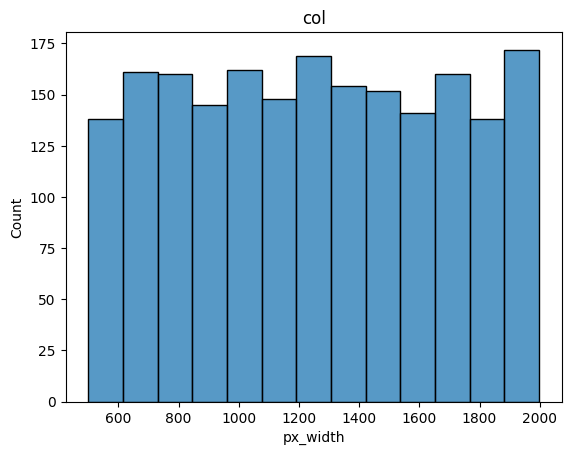

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


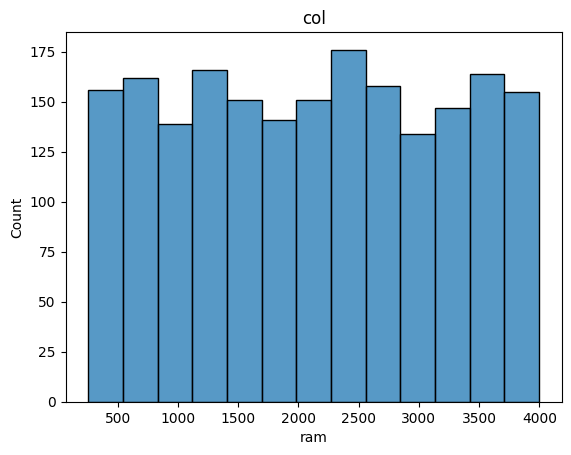

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


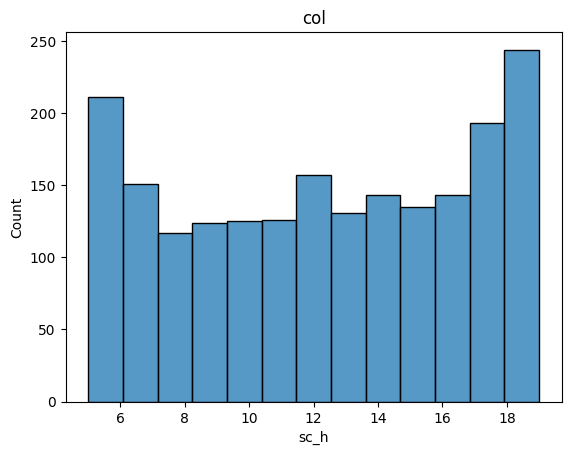

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


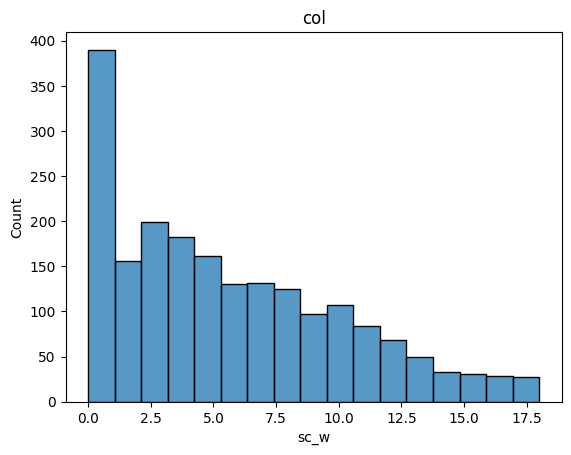

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


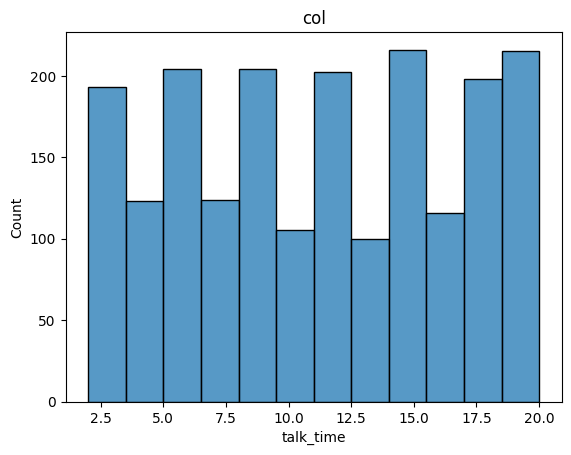

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


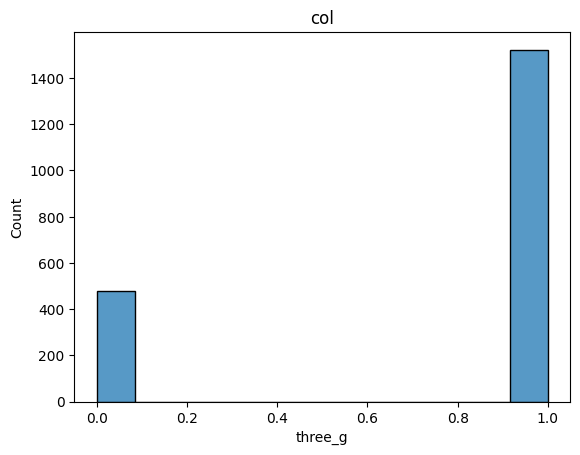

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


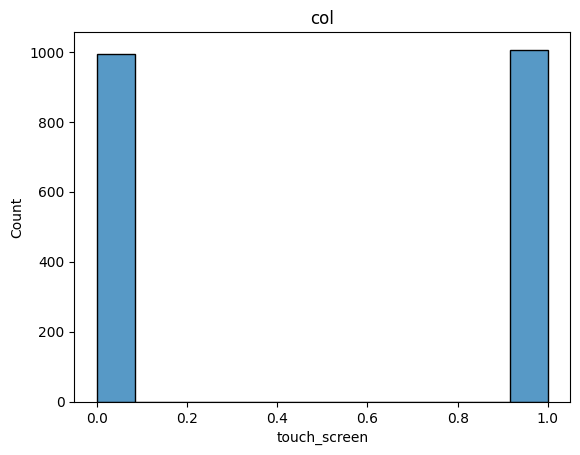

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


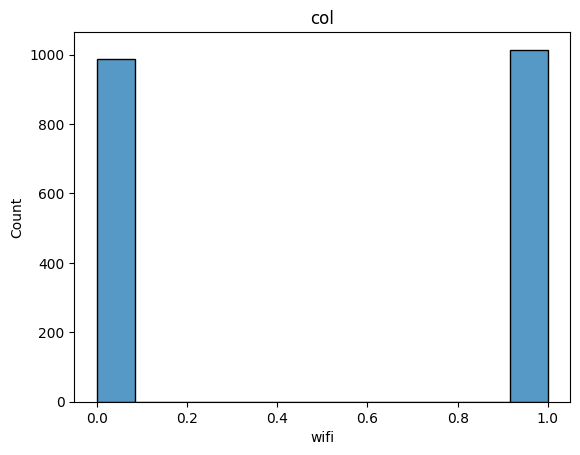

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


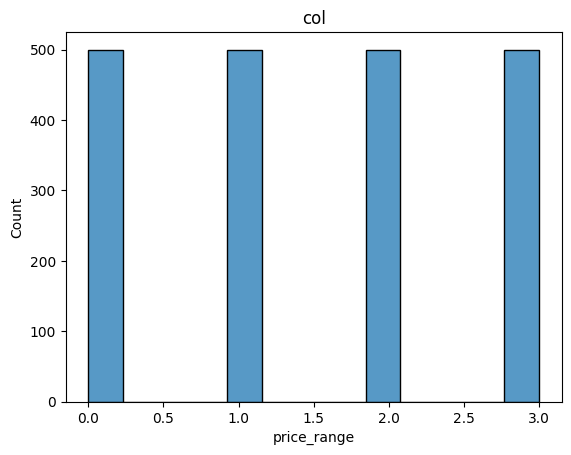

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


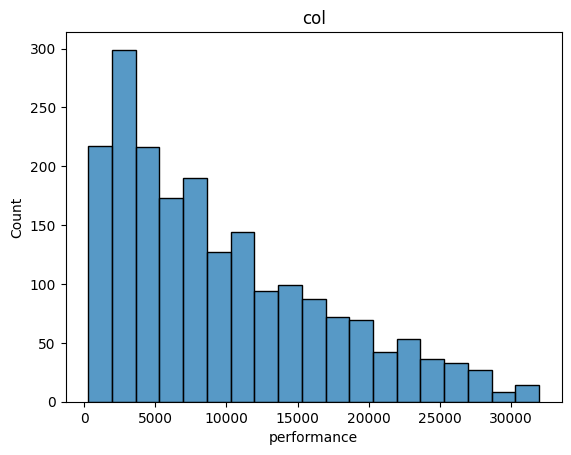

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


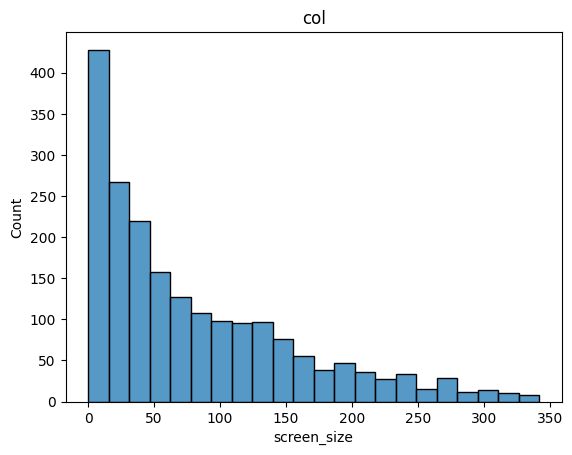

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


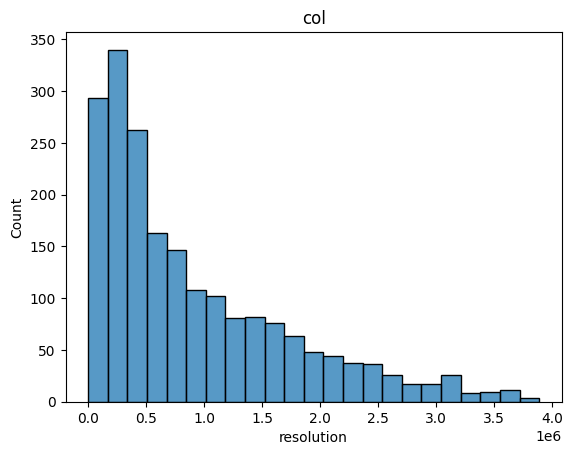

In [64]:
for col in df.columns:
    sns.histplot(data=df, x=col)
    plt.title(f"col")
    plt.show()
    

Several numerical features such as battery_power, internal_memory, number of cores, primary camera, RAM, and price_range show a wide distribution, indicating a high variability across devices.

Binary features such as Bluetooth and dual SIM are relatively balanced, suggesting that these characteristics are evenly distributed among devices.

Clock speed is concentrated at lower values, indicating that most devices have relatively low processing speed.

Features such as front camera resolution, pixel height, performance, screen size, and overall resolution are right-skewed, meaning that most devices have lower values, with fewer high-end devices.

Finally, most devices support 4G connectivity, indicating that this feature is widely adopted.

Although some features such as RAM and battery power are widely spread, this variability actually makes them more informative. A wide distribution allows these features to better differentiate between price categories, which explains their strong relationship with the target variable.

The target variable is evenly distributed across the four price categories, indicating a balanced dataset. However, this does not imply that prices are uniformly distributed in reality, but rather that the dataset has been intentionally constructed to contain an equal number of observations in each class.

Some features such as front camera, resolution, and performance are right-skewed, indicating that high specification values are less common.

However, this does not imply that high-end devices are rare, as the target variable (price_range) is evenly distributed across classes.